## Business Problem
A bank receives thousands of loan applications every month.

Some customers repay on time, while others default on their loans.


## Business Objective

Predict whether a loan applicant is likely to default before approving the loan.

In [1]:
print('Hello World')

Hello World


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt  
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score,classification_report,f1_score,recall_score,precision_score,confusion_matrix 
from sklearn.inspection import permutation_importance

In [3]:
df = pd.read_csv("Loan_default.csv")
df.head(10)

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0
5,A9S62RQ7US,25,90298,90448,720,18,2,22.72,24,0.10,High School,Unemployed,Single,Yes,No,Business,Yes,1
6,H8GXPAOS71,38,111188,177025,429,80,1,19.11,12,0.16,Bachelor's,Unemployed,Single,Yes,No,Home,Yes,0
7,0HGZQKJ36W,56,126802,155511,531,67,4,8.15,60,0.43,PhD,Full-time,Married,No,No,Home,Yes,0
8,1R0N3LGNRJ,36,42053,92357,827,83,1,23.94,48,0.20,Bachelor's,Self-employed,Divorced,Yes,No,Education,No,1
9,CM9L1GTT2P,40,132784,228510,480,114,4,9.09,48,0.33,High School,Self-employed,Married,Yes,No,Other,Yes,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  str    
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  str    
 11  EmploymentType  255347 non-null  str    
 12  MaritalStatus   255347 non-null  str    
 13  HasMortgage     255347 non-null  str    
 14  HasDependents   255347 non-null  str    
 15  LoanPurpose     255347 non-null  str    
 16  HasCoSigner     255347 non-null  str    
 17  Default         25534

In [5]:
df.isnull().sum()

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

In [6]:
default_rate = df["Default"].mean()
print("Default rate : ",round(default_rate*100,2),"%")

Default rate :  11.61 %


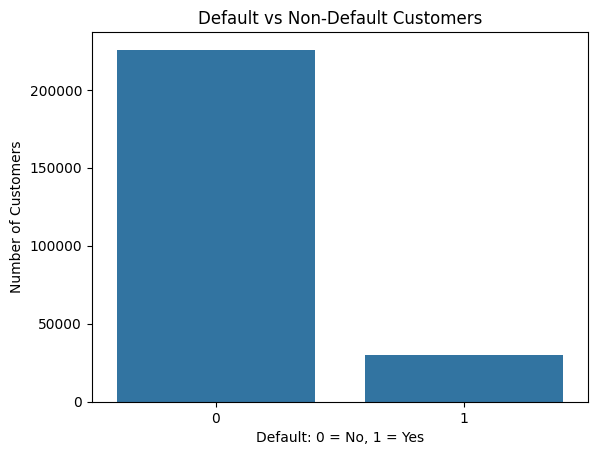

In [7]:
sns.countplot(data=df, x="Default")
plt.title("Default vs Non-Default Customers")
plt.xlabel("Default: 0 = No, 1 = Yes")
plt.ylabel("Number of Customers")
plt.show()

In [8]:
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [10]:
profile_table = df.groupby("Default")[[
    "Age", "Income", "LoanAmount", "CreditScore", "MonthsEmployed",
    "InterestRate", "LoanTerm", "DTIRatio"
]].mean()

profile_table

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,InterestRate,LoanTerm,DTIRatio
Default,,,,,,,,
0,44.409962,83899.165995,125353.656017,576.232270,60.764721,13.176994,36.022544,0.498602
1,36.559539,71844.722659,144515.311469,559.286143,50.235457,15.896227,36.051394,0.512467


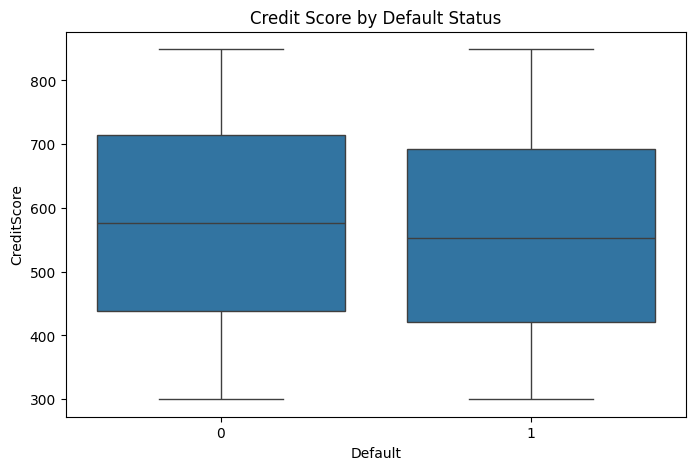

In [11]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Default", y="CreditScore")
plt.title("Credit Score by Default Status")
plt.show()

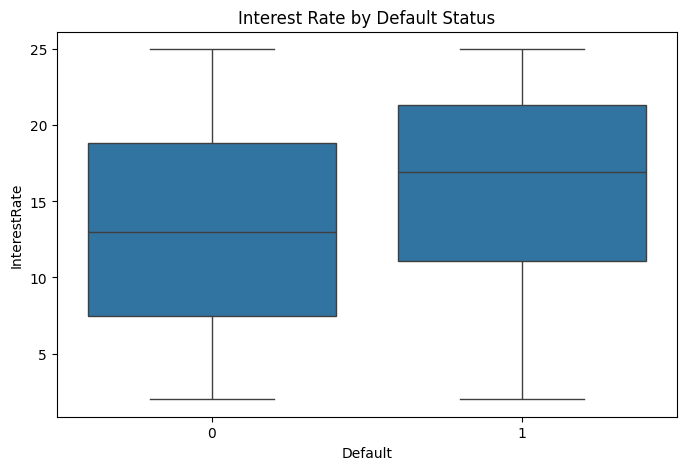

In [12]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Default", y="InterestRate")
plt.title("Interest Rate by Default Status")
plt.show()

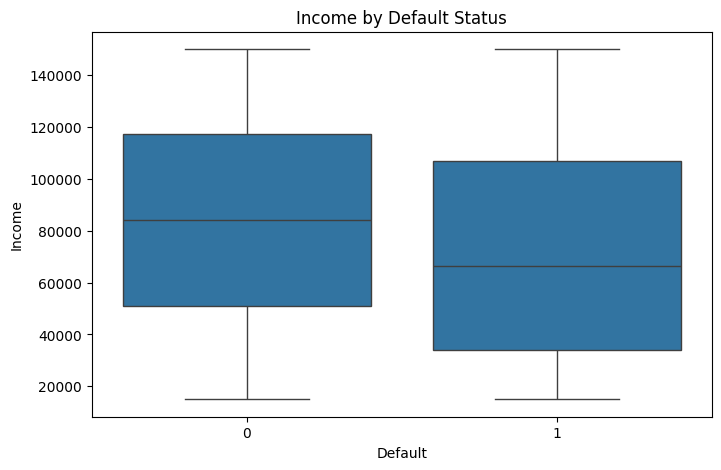

In [13]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Default", y="Income")
plt.title("Income by Default Status")
plt.show()

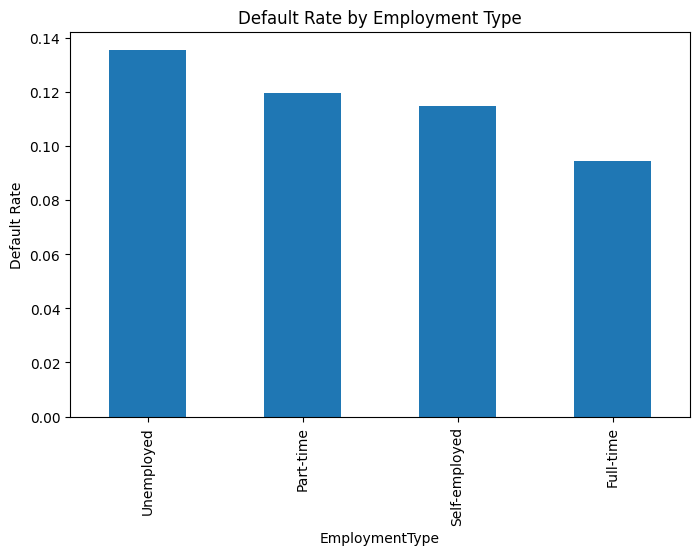

In [14]:
# Default rate by employment type
employment_default = df.groupby("EmploymentType")["Default"].mean().sort_values(ascending=False)

employment_default.plot(kind="bar", figsize=(8, 5))
plt.title("Default Rate by Employment Type")
plt.ylabel("Default Rate")
plt.show()

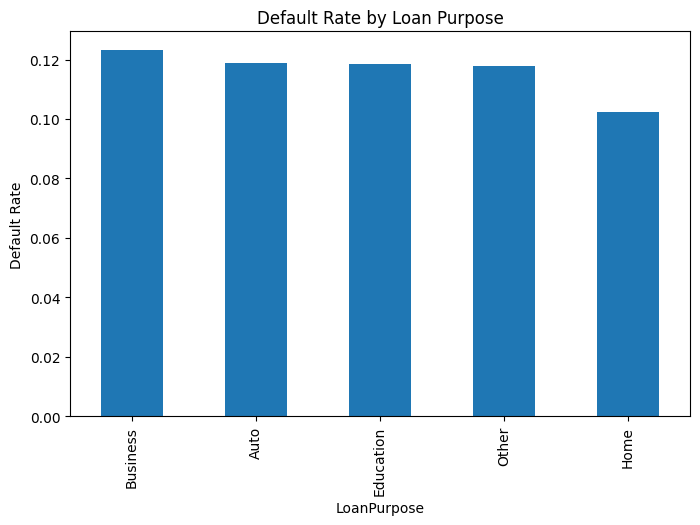

In [15]:
# Default rate by loan purpose
purpose_default = df.groupby("LoanPurpose")["Default"].mean().sort_values(ascending=False)

purpose_default.plot(kind="bar", figsize=(8, 5))
plt.title("Default Rate by Loan Purpose")
plt.ylabel("Default Rate")
plt.show()

In [16]:
X = df.drop(["LoanID", "Default"], axis=1)
y = df["Default"]

In [17]:
numeric_columns = X.select_dtypes(include=["int64", "float64"]).columns
categorical_columns = X.select_dtypes(include=["object", "string"]).columns

print("Numeric columns:", list(numeric_columns))
print("Categorical columns:", list(categorical_columns))

Numeric columns: ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio']
Categorical columns: ['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 204277
Testing rows: 51070


In [19]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_columns),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_columns)
    ]
)

model = HistGradientBoostingClassifier(
    max_iter=160,
    learning_rate=0.06,
    random_state=42
)

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", model)
])

In [20]:
pipeline.fit(X_train, y_train)

print("Model training completed")

Model training completed


In [ ]:
risk_probability = pipeline.predict_proba(X_test)[:, 1]

results = []

for threshold in np.arange(0.05, 0.51, 0.01):
    y_pred = (risk_probability >= threshold).astype(int)
    
    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred)
    
    results.append([threshold, accuracy, recall, precision, f1])

threshold_results = pd.DataFrame(results, columns=["Threshold", "Accuracy", "Default Recall", "Default Precision", "F1 Score"])

threshold_results.head()

,Threshold,Accuracy,Default Recall,Default Precision,F1 Score
0,0.05,0.373546,0.930366,0.148741,0.256478
1,0.06,0.444096,0.895127,0.160504,0.272201
2,0.07,0.508126,0.855674,0.172978,0.287780
3,0.08,0.561895,0.818243,0.185590,0.302556
4,0.09,0.609125,0.782667,0.199099,0.317445


In [ ]:
valid_thresholds = threshold_results[threshold_results["Accuracy"] >= 0.75]

best_row = valid_thresholds.sort_values("Default Recall", ascending=False).iloc[0]

best_threshold = best_row["Threshold"]

best_row

Threshold            0.140000
Accuracy             0.751694
Default Recall       0.601248
Default Precision    0.256879
F1 Score             0.359966
Name: 9, dtype: float64

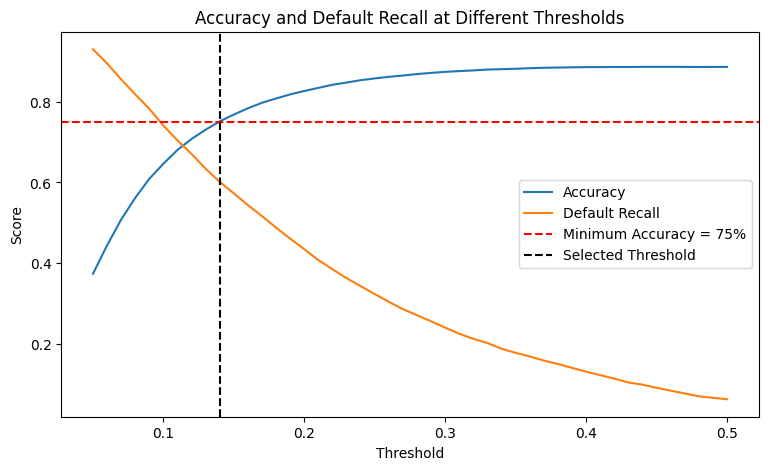

In [23]:
plt.figure(figsize=(9, 5))
plt.plot(threshold_results["Threshold"], threshold_results["Accuracy"], label="Accuracy")
plt.plot(threshold_results["Threshold"], threshold_results["Default Recall"], label="Default Recall")
plt.axhline(0.75, color="red", linestyle="--", label="Minimum Accuracy = 75%")
plt.axvline(best_threshold, color="black", linestyle="--", label="Selected Threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Accuracy and Default Recall at Different Thresholds")
plt.legend()
plt.show()

In [24]:
y_pred_final = (risk_probability >= best_threshold).astype(int)

final_accuracy = accuracy_score(y_test, y_pred_final)
final_recall = recall_score(y_test, y_pred_final)
final_precision = precision_score(y_test, y_pred_final)
final_f1 = f1_score(y_test, y_pred_final)

print("Selected Threshold:", round(best_threshold, 2))
print("Final Accuracy:", round(final_accuracy * 100, 2), "%")
print("Default Recall:", round(final_recall * 100, 2), "%")
print("Default Precision:", round(final_precision * 100, 2), "%")
print("F1 Score:", round(final_f1 * 100, 2), "%")

Selected Threshold: 0.14
Final Accuracy: 75.17 %
Default Recall: 60.12 %
Default Precision: 25.69 %
F1 Score: 36.0 %


In [25]:
print(classification_report(y_test, y_pred_final, target_names=["Non-Default", "Default"]))

              precision    recall  f1-score   support

 Non-Default       0.94      0.77      0.85     45139
     Default       0.26      0.60      0.36      5931

    accuracy                           0.75     51070
   macro avg       0.60      0.69      0.60     51070
weighted avg       0.86      0.75      0.79     51070



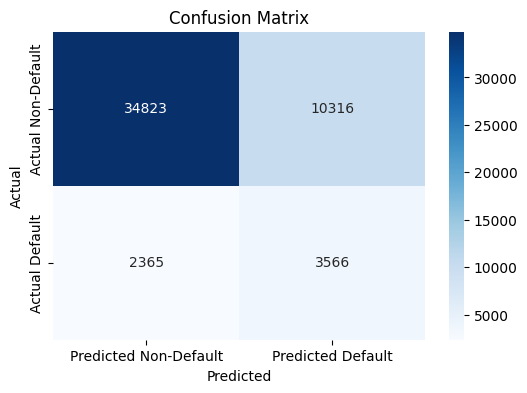

True Positives  = Default customers correctly identified
False Negatives = Default customers missed by the model
For this project, we mainly want to reduce False Negatives.


In [26]:
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Non-Default", "Predicted Default"],
    yticklabels=["Actual Non-Default", "Actual Default"]
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("True Positives  = Default customers correctly identified")
print("False Negatives = Default customers missed by the model")
print("For this project, we mainly want to reduce False Negatives.")

In [27]:
approved = risk_probability < best_threshold

approved_actual_values = y_test[approved]
loan_approval_accuracy = (approved_actual_values == 0).mean()
approval_rate = approved.mean()

print("Approval Rate:", round(approval_rate * 100, 2), "%")
print("Loan Approval Accuracy:", round(loan_approval_accuracy * 100, 2), "%")

Approval Rate: 72.82 %
Loan Approval Accuracy: 93.64 %


In [ ]:
baseline_loss = X_test.loc[y_test == 1, "LoanAmount"].sum()

approved_default_loss = X_test.loc[approved & (y_test == 1), "LoanAmount"].sum()

financial_loss_reduction = 1 - (approved_default_loss / baseline_loss)

print("Baseline Default Loss:", round(baseline_loss, 2))
print("Default Loss After Model:", round(approved_default_loss, 2))
print("Financial Loss Reduction:", round(financial_loss_reduction * 100, 2), "%")

Baseline Default Loss: 859551069
Default Loss After Model: 295654010
Financial Loss Reduction: 65.6 %


In [ ]:
sample_size = 10000
X_sample = X_test.sample(sample_size, random_state=42)
y_sample = y_test.loc[X_sample.index]

importance = permutation_importance(
    pipeline,
    X_sample,
    y_sample,
    scoring="recall",
    n_repeats=3,
    random_state=42
)

importance_table = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance.importances_mean
}).sort_values("Importance", ascending=False)

importance_table

,Feature,Importance
1,Income,0.031463
0,Age,0.022959
2,LoanAmount,0.021542
6,InterestRate,0.016156
4,MonthsEmployed,0.011905
10,EmploymentType,0.010488
15,HasCoSigner,0.005102
12,HasMortgage,0.005102
13,HasDependents,0.005102
9,Education,0.004535


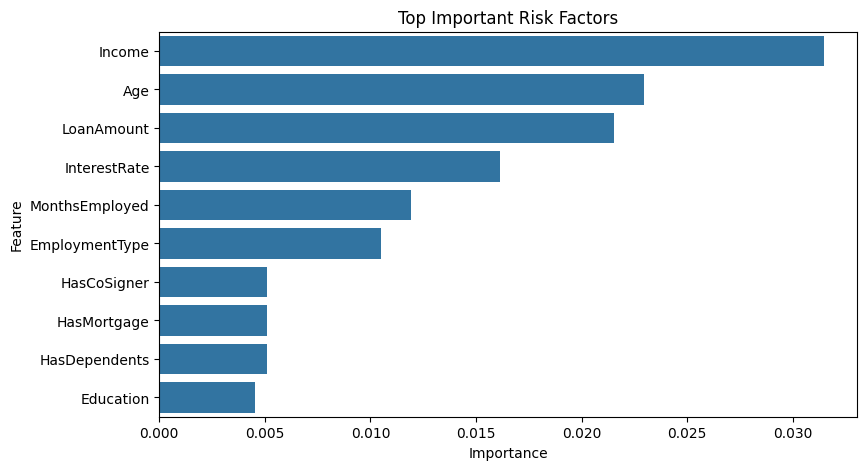

In [30]:
plt.figure(figsize=(9, 5))
sns.barplot(data=importance_table.head(10), x="Importance", y="Feature")
plt.title("Top Important Risk Factors")
plt.show()

In [ ]:
high_risk_result = X_test.copy()
high_risk_result["Actual_Default"] = y_test
high_risk_result["Default_Risk_Probability"] = risk_probability
high_risk_result["Predicted_Default"] = y_pred_final

high_risk_result["LoanID"] = df.loc[X_test.index, "LoanID"]

high_risk_applicants = high_risk_result[high_risk_result["Predicted_Default"] == 1]

high_risk_applicants = high_risk_applicants.sort_values("Default_Risk_Probability", ascending=False)

print("Number of high-risk applicants:", high_risk_applicants.shape[0])

high_risk_applicants[[
    "LoanID", "Age", "Income", "LoanAmount", "CreditScore", "MonthsEmployed",
    "InterestRate", "DTIRatio", "EmploymentType", "LoanPurpose",
    "Default_Risk_Probability", "Predicted_Default", "Actual_Default"
]].head(20)

Number of high-risk applicants: 13882


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,InterestRate,DTIRatio,EmploymentType,LoanPurpose,Default_Risk_Probability,Predicted_Default,Actual_Default
183638,7TG0IAGBUB,28,17005,191670,392,19,19.12,0.53,Unemployed,Other,0.841871,1,1
180698,YIG4YDL0G8,34,15689,235553,461,16,18.32,0.87,Part-time,Business,0.840178,1,1
63485,PWXSX53FPI,19,16102,205502,443,7,17.42,0.70,Self-employed,Business,0.833199,1,1
181736,20A1MCI2BA,25,15224,231350,556,20,20.32,0.21,Unemployed,Business,0.829260,1,1
225315,L1O3DOQLOM,20,15557,221362,457,30,17.16,0.55,Part-time,Other,0.821154,1,1
231579,HVSI7D31F6,20,15984,222769,800,49,23.40,0.87,Unemployed,Business,0.807394,1,1
179086,MJT6H4RK1R,43,15522,241765,454,10,18.11,0.22,Unemployed,Auto,0.793872,1,1
91870,0R4C60BNGX,23,18556,235573,647,0,15.60,0.60,Part-time,Business,0.783872,1,1
28526,BB72OA8NE3,26,20505,207654,403,3,17.50,0.77,Self-employed,Auto,0.781588,1,1
244575,HH0HFW25FQ,24,15568,214404,520,11,18.97,0.54,Unemployed,Auto,0.775580,1,0


In [32]:
summary = pd.DataFrame({
    "KPI": [
        "Default Rate",
        "Final Model Accuracy",
        "Default Class Recall",
        "Loan Approval Accuracy",
        "Financial Loss Reduction",
        "Number of High-Risk Applicants"
    ],
    "Value": [
        str(round(default_rate * 100, 2)) + "%",
        str(round(final_accuracy * 100, 2)) + "%",
        str(round(final_recall * 100, 2)) + "%",
        str(round(loan_approval_accuracy * 100, 2)) + "%",
        str(round(financial_loss_reduction * 100, 2)) + "%",
        high_risk_applicants.shape[0]
    ]
})

summary

,KPI,Value
0,Default Rate,11.61%
1,Final Model Accuracy,75.17%
2,Default Class Recall,60.12%
3,Loan Approval Accuracy,93.64%
4,Financial Loss Reduction,65.6%
5,Number of High-Risk Applicants,13882
